<a href="https://colab.research.google.com/github/lialegael55-blip/LAB/blob/main/Lesson_7_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Assignment Supervised machine Learning - Regression**

### **_House Price Prediction Using Bolton Housing Data_**
This dataset provides information about house prices in Bolton. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "Boston Housing Dataset" from sklearn. The regression model will either be a Decision Tree or Random Forest regressor.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (Bolton Housing):

* CRIM: Crime rate by town
* ZN: Proportion of residential land zoned for large lots
* INDUS: Proportion of non-retail business acres per town
* CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
* NOX: Nitric oxide concentration (parts per 10 million)
* RM: Average number of rooms per dwelling
* AGE: Proportion of owner-occupied units built before 1940
* DIS: Weighted distances to five Boston employment centers
* RAD: Index of accessibility to radial highways
* TAX: Full-value property tax rate per `$10,000`
* PTRATIO: Pupil-teacher ratio by town
* B: Proportion of Black population
* LSTAT: Percentage of lower status of the population
* MEDV (Target): Median value of owner-occupied homes in `$1,000s`



**Dataset is from sklearn Datasets**

In [9]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

Data Collection and Loading

# Load dataset


In [10]:
from sklearn.datasets import fetch_openml

# Load directly as DataFrame
boston = fetch_openml(name='boston', version=1, as_frame=True)

df = boston.frame  # already includes features + target

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


🔹 3. Quick Data Check


In [11]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


4. Check Missing Values

In [12]:
df.isnull().sum()


,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


EDA – Visualization

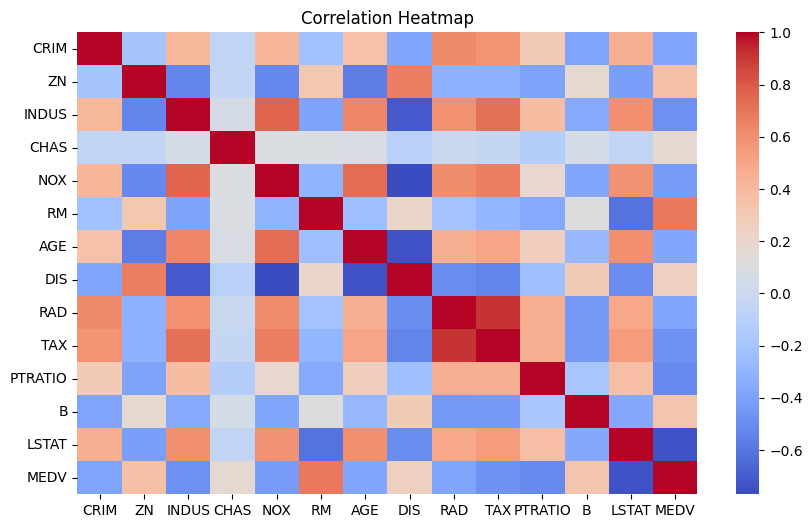

In [13]:
#Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [14]:
print("""
EDA Insights:
- RM (average rooms) shows a positive relationship with house prices.
- LSTAT (lower-status population percentage) shows a strong negative relationship with house prices.
- Several features have moderate correlations with MEDV.
- No missing values were found in the dataset.
""")


EDA Insights:
- RM (average rooms) shows a positive relationship with house prices.
- LSTAT (lower-status population percentage) shows a strong negative relationship with house prices.
- Several features have moderate correlations with MEDV.
- No missing values were found in the dataset.



In [15]:
print("RM shows a strong positive relationship with house prices.")
print("LSTAT shows a strong negative relationship with house prices.")

RM shows a strong positive relationship with house prices.
LSTAT shows a strong negative relationship with house prices.


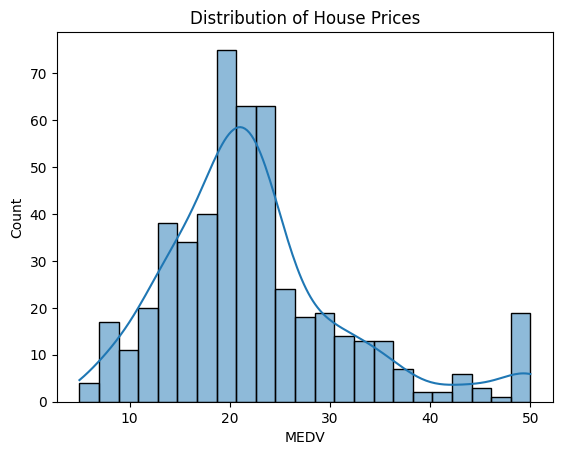

In [16]:
sns.histplot(df['MEDV'], kde=True)
plt.title('Distribution of House Prices')
plt.show()

The histogram shows the distribution of the target variable MEDV (Median House Value). Most houses have prices between approximately 15 and 30 thousand dollars, with the highest concentration around 20–25 thousand dollars.
Key observations:

The distribution is slightly right-skewed (positively skewed), meaning there are fewer houses with very high prices compared to houses with moderate prices.
Most properties fall within the middle price range, indicating that the dataset is dominated by average-priced homes.
There is a noticeable cluster of observations near the maximum value of 50, suggesting the dataset may contain a price ceiling where higher values were capped.
The presence of high-value houses can influence model performance and should be considered during model evaluation.

Conclusion: The target variable is not perfectly normally distributed and contains some high-priced observations that may affect prediction accuracy.

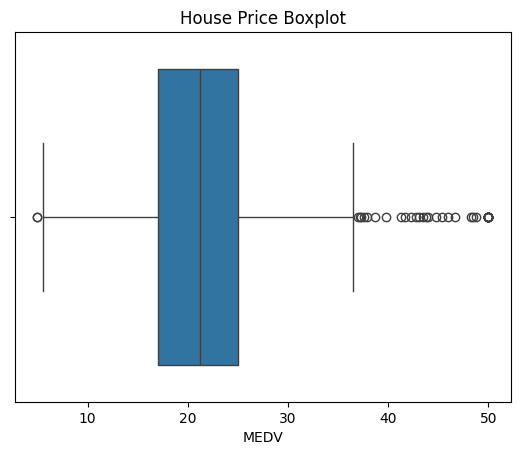

In [30]:

# Boxplot
sns.boxplot(x=df['MEDV'])
plt.title('House Price Boxplot')
plt.show()


The boxplot provides additional information about the spread and outliers in house prices.
Key observations:

The median house price is approximately 21–22 thousand dollars, shown by the line inside the box.
The middle 50% of house prices (Interquartile Range) lies roughly between 17 and 25 thousand dollars.
Several outliers are visible on the upper end of the distribution, with house prices reaching up to 50 thousand dollars.
There is also a single low-value outlier near 5 thousand dollars.
The larger number of upper outliers confirms the positive skewness observed in the histogram.

Conclusion: House prices show moderate variability, with most values concentrated around the median. However, several expensive properties exist as outliers, which may impact regression models and should be considered when interpreting prediction errors.

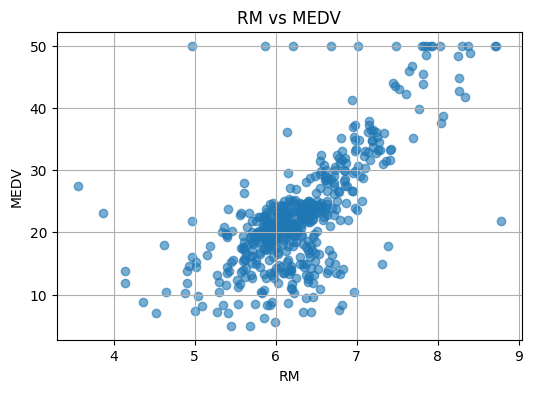

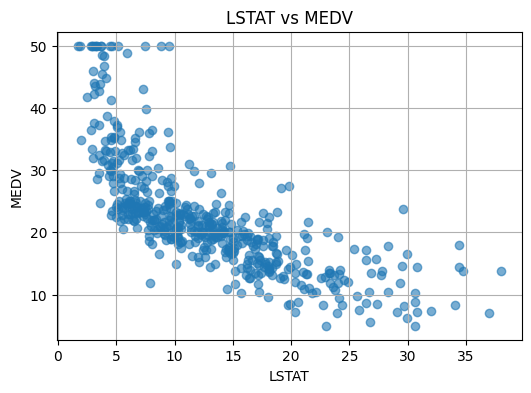

In [38]:
def scatter_plot(feature):
    plt.figure(figsize=(6,4))
    plt.scatter(df[feature], df['MEDV'], alpha=0.6)
    plt.xlabel(feature)
    plt.ylabel('MEDV')
    plt.title(f'{feature} vs MEDV')
    plt.grid(True)
    plt.show()
# Example
scatter_plot('RM')
scatter_plot('LSTAT')

6. Prepare Data

In [18]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']

7. Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

8. Choose Model

In [20]:
#Option 1: Decision Tree
model = DecisionTreeRegressor(random_state=42)

In [21]:
#Option 2: Random Forest (recommended for better performance)
model = RandomForestRegressor(n_estimators=100, random_state=42)


9. Train Model

In [22]:
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

10. Model Prediction


In [23]:
y_pred = model.predict(X_test)

11. Model Evaluation


In [36]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

print("Decision Tree R²:", dt_model.score(X_test, y_test))
print("Random Forest R²:", rf_model.score(X_test, y_test))

Decision Tree R²: 0.8579634380978161
Random Forest R²: 0.8922527442109116


In [24]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 2.8109631609391226
R2 Score: 0.8922527442109116


🔹 12. Overfitting Check


In [25]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R2:", train_score)
print("Test R2:", test_score)

Train R2: 0.9772267182453291
Test R2: 0.8922527442109116


13. Parameter Tuning

In [26]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)
y_pred_tuned = model.predict(X_test)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned RMSE:", rmse_tuned)
print("Tuned R²:", r2_tuned)

Tuned RMSE: 3.021345834978759
Tuned R²: 0.8755208000849128


14. Feature Importance

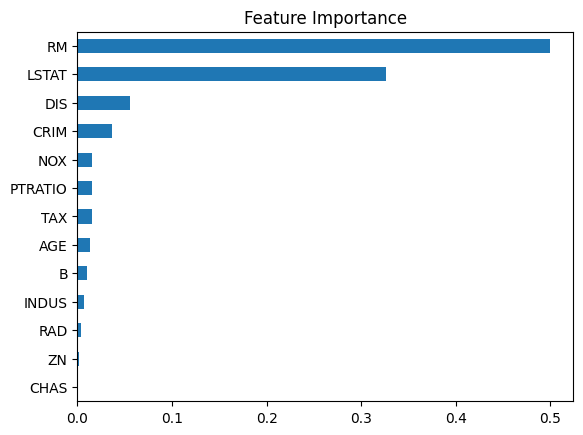

In [27]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

15. Predict on New Data


In [28]:
new_data = pd.DataFrame([{
    'CRIM': 0.2,
    'ZN': 12.5,
    'INDUS': 7.07,
    'CHAS': 0,
    'NOX': 0.5,
    'RM': 6.5,
    'AGE': 68,
    'DIS': 4.0,
    'RAD': 2,
    'TAX': 250,
    'PTRATIO': 17,
    'B': 400,
    'LSTAT': 12
}])

prediction = model.predict(new_data)
print("Predicted House Price:", prediction)

Predicted House Price: [22.22981617]


In [29]:
print("Interpretation:")
print("- Lower RMSE indicates better prediction accuracy.")
print("- Higher R² indicates the model explains more variance in house prices.")
print("- The Random Forest model performed well on unseen test data.")

Interpretation:
- Lower RMSE indicates better prediction accuracy.
- Higher R² indicates the model explains more variance in house prices.
- The Random Forest model performed well on unseen test data.


In [37]:
print("""
Final Conclusion

The Random Forest Regressor achieved strong predictive performance with a high R² score and low RMSE.

Feature importance analysis showed that:
- RM (number of rooms) was the strongest predictor.
- LSTAT was the second most important predictor.

The model generalized well to unseen test data, indicating limited overfitting and good predictive capability.
""")


Final Conclusion

The Random Forest Regressor achieved strong predictive performance with a high R² score and low RMSE.

Feature importance analysis showed that:
- RM (number of rooms) was the strongest predictor.
- LSTAT was the second most important predictor.

The model generalized well to unseen test data, indicating limited overfitting and good predictive capability.

